# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [25]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [26]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "217746"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v86bd06c0
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.068434,0.142314,1.439959,1.255784,0.257197,-1.640281,0.982262,92.597121,1.850238,0.154532,-1.801898,-1.272056,10.645796
1,1.042498,0.362305,1.334760,0.553136,-0.449122,2.984783,0.433549,4.550458,2.728899,-0.255231,-1.505692,-1.192053,6.318747
2,1.625906,0.339635,1.320714,-1.212849,-1.245658,2.621532,0.881984,91.912080,0.972858,-0.225379,-1.340934,-0.336714,18.986289
3,15.939307,0.152425,1.450290,1.879365,0.371861,-0.733249,0.138374,19.513928,0.653114,0.491327,-1.596501,-0.790144,21.200935
4,3.107326,0.324494,1.480220,0.677291,2.201735,-1.110639,-1.249218,41.704120,0.964409,0.221824,-0.186848,1.724695,18.042366


In [27]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? 
#x1     25.272745
#x2      0.998493
#x3     33.559832
#x4      3.992489
#x5      5.897260
#x6      5.984868
#x7      5.986193
#x8     99.507323
#x9      3.992839
#x10     0.998108
#x11     7.158420
#x12     3.972805
#y      99.690192

#¿Hay faltantes? No
train.describe().T

train.info()

print(train.max()-train.min())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      800 non-null    float64
 1   x2      800 non-null    float64
 2   x3      800 non-null    float64
 3   x4      800 non-null    float64
 4   x5      800 non-null    float64
 5   x6      800 non-null    float64
 6   x7      800 non-null    float64
 7   x8      800 non-null    float64
 8   x9      800 non-null    float64
 9   x10     800 non-null    float64
 10  x11     800 non-null    float64
 11  x12     800 non-null    float64
 12  y       800 non-null    float64
dtypes: float64(13)
memory usage: 81.4 KB
x1     25.272745
x2      0.998493
x3     33.559832
x4      3.992489
x5      5.897260
x6      5.984868
x7      5.986193
x8     99.507323
x9      3.992839
x10     0.998108
x11     7.158420
x12     3.972805
y      99.690192
dtype: float64


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 112.51
R² del baseline en validación : 0.293

Desviación estándar de y: 13.51


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x2'}>,
        <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x5'}>,
        <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x8'}>,
        <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x11'}>,
        <Axes: title={'center': 'x12'}>]], dtype=object)

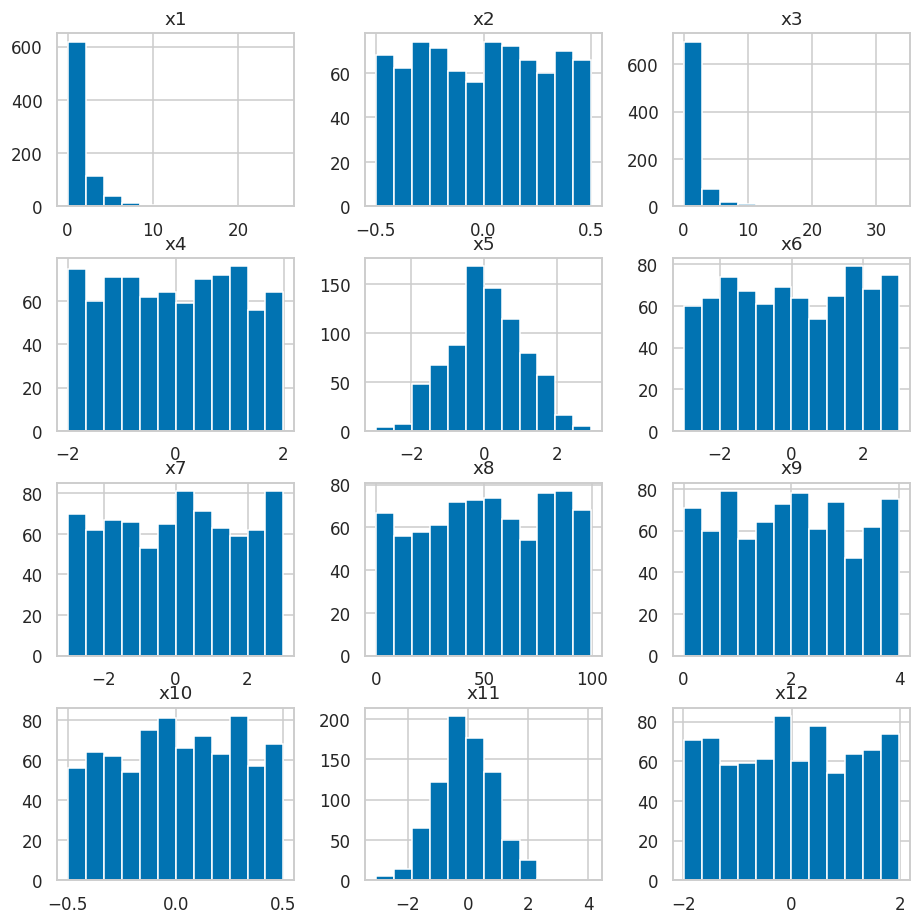

In [29]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.

train[VARIABLES].hist(bins=12, figsize=(10,10))

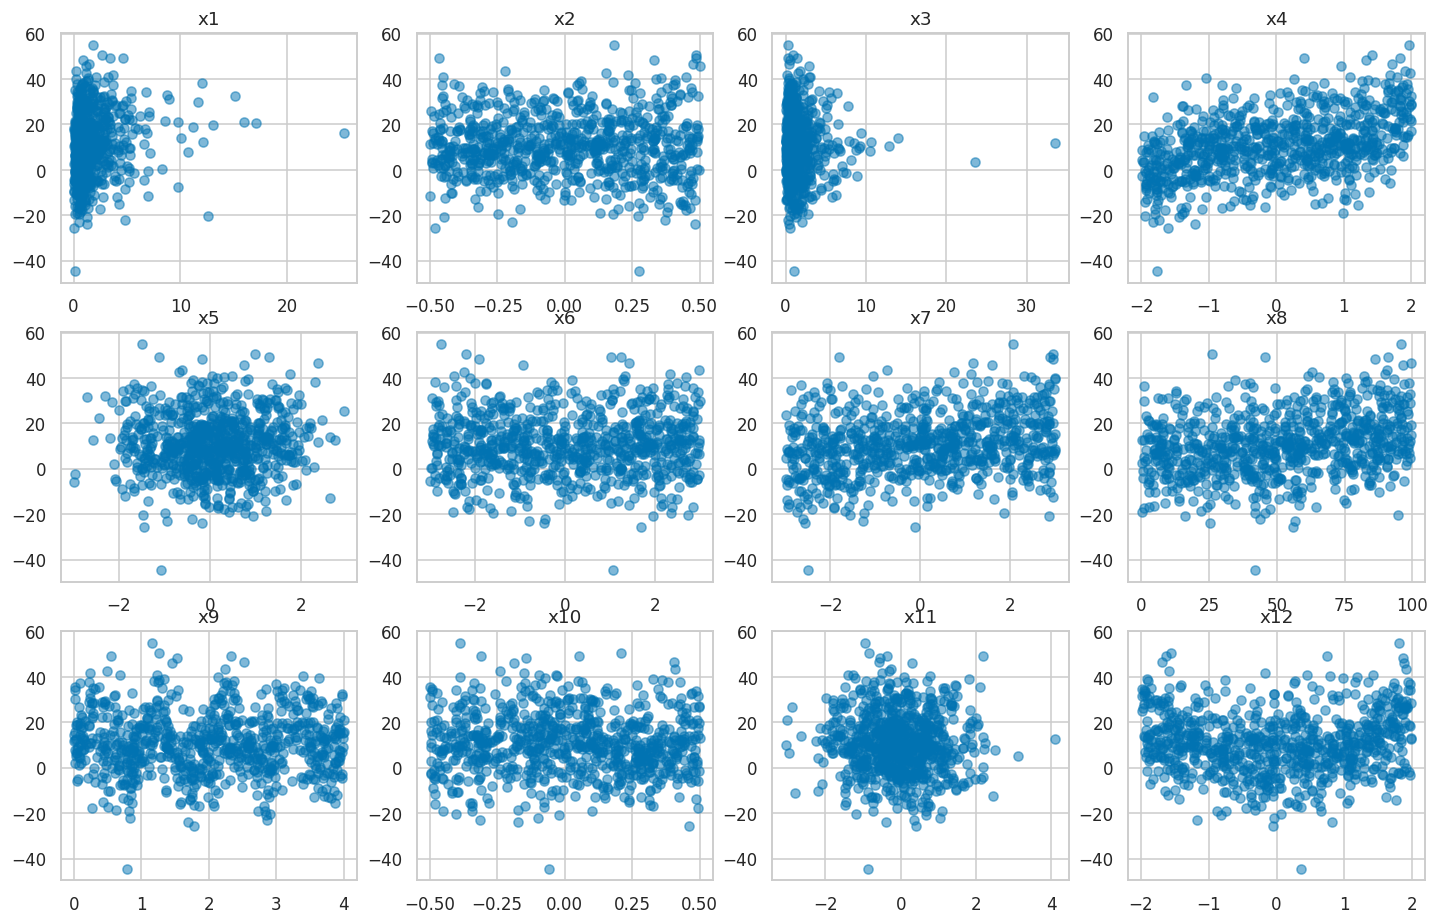

In [30]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.

plt.figure(figsize=(16, 10))
for i in range(1, 13):
    plt.subplot(3, 4, i)
    plt.scatter(train["x" + str(i)], train["y"], alpha=0.5)
    plt.title("x"+str(i))
    

In [31]:
# TODO: matriz de correlación entre las 12 variables y `y`.

train[VARIABLES + ['y']].corr()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
x1,1.000000,0.033727,-0.054571,-0.003744,0.064950,0.010345,0.035106,-0.055962,0.076630,0.010488,0.043472,0.042573,0.160104
x2,0.033727,1.000000,-0.026181,0.048158,0.030932,-0.046013,-0.046967,0.035703,-0.069217,-0.018985,-0.019218,-0.017180,-0.001895
x3,-0.054571,-0.026181,1.000000,-0.080274,-0.018230,0.045279,0.018386,0.036244,-0.002054,0.006492,-0.063115,-0.020397,-0.028458
x4,-0.003744,0.048158,-0.080274,1.000000,0.068956,0.008812,0.009608,-0.031492,0.028924,-0.062991,-0.007013,-0.011814,0.452195
x5,0.064950,0.030932,-0.018230,0.068956,1.000000,-0.006095,0.006309,-0.031425,-0.035372,-0.027548,0.010037,-0.034731,0.033048
x6,0.010345,-0.046013,0.045279,0.008812,-0.006095,1.000000,-0.012106,-0.045851,-0.051118,-0.027733,-0.021668,0.003928,0.018162
x7,0.035106,-0.046967,0.018386,0.009608,0.006309,-0.012106,1.000000,0.035880,0.019070,0.010358,-0.043985,0.004377,0.260357
x8,-0.055962,0.035703,0.036244,-0.031492,-0.031425,-0.045851,0.035880,1.000000,0.034824,0.016420,-0.035066,0.051557,0.274746
x9,0.076630,-0.069217,-0.002054,0.028924,-0.035372,-0.051118,0.019070,0.034824,1.000000,-0.012247,0.055769,0.009783,-0.021856
x10,0.010488,-0.018985,0.006492,-0.062991,-0.027548,-0.027733,0.010358,0.016420,-0.012247,1.000000,-0.015278,-0.015898,-0.051169


### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
| --- | --- | --- | --- |
| x1 | Relación no lineal (necesita transformacion) | "Dispersión x1 vs y (Fila 1, Col 1)"|Seguro|
| x2 | Sin relación lineal (ruido blanco) | "Dispersión x2 vs y (Fila 1, Col 2)" |Muy seguro|
| x3 | Acumulación masiva cerca de 0, no relacionada aunque una transformacion podria ayudar |"Dispersión x3 vs y (Fila 1, Col 3)"|Seguro|
| x4 | Relación lineal positiva clara y marcada|"Dispersión x4 vs y (Fila 1, Col 4)"|Muy seguro|
| x5 | Sin relación lineal (ruido uniforme)|"Dispersión x5 vs y (Fila 2, Col 1)"|Muy seguro|
| x6 | Sin relación lineal (ruido uniforme)|"Dispersión x6 vs y (Fila 2, Col 2)"|Muy seguro|
| x7 | Relación lineal positiva moderada|"Dispersión x7 vs y (Fila 2, Col 3)"|Seguro|
| x8 | Relación lineal positiva moderada|"Dispersión x8 vs y (Fila 2, Col 4)"|Seguro|
| x9 | Patrón periódico (forma de ola) escondido en el ruido|"Dispersión x9 vs y (Fila 3, Col 1)"|Mas o menos|
| x10 |Sin relación lineal (ruido uniforme)|"Dispersión x10 vs y (Fila 3, Col 2)"|Muy seguro|
| x11 |Sin relación lineal (ruido uniforme)|"Dispersión x11 vs y (Fila 3, Col 3)"|Muy seguro|
| x12 |Parábola centrada en 0, talvez mas relacion si se transforma|"Dispersión x12 vs y (Fila 3, Col 4)"|Mas o menos|


Muy seguro es de 90% o mas

Seguro es entre un 70%-90%

Mas o menos es entre 50%-70%

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [32]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 112.51


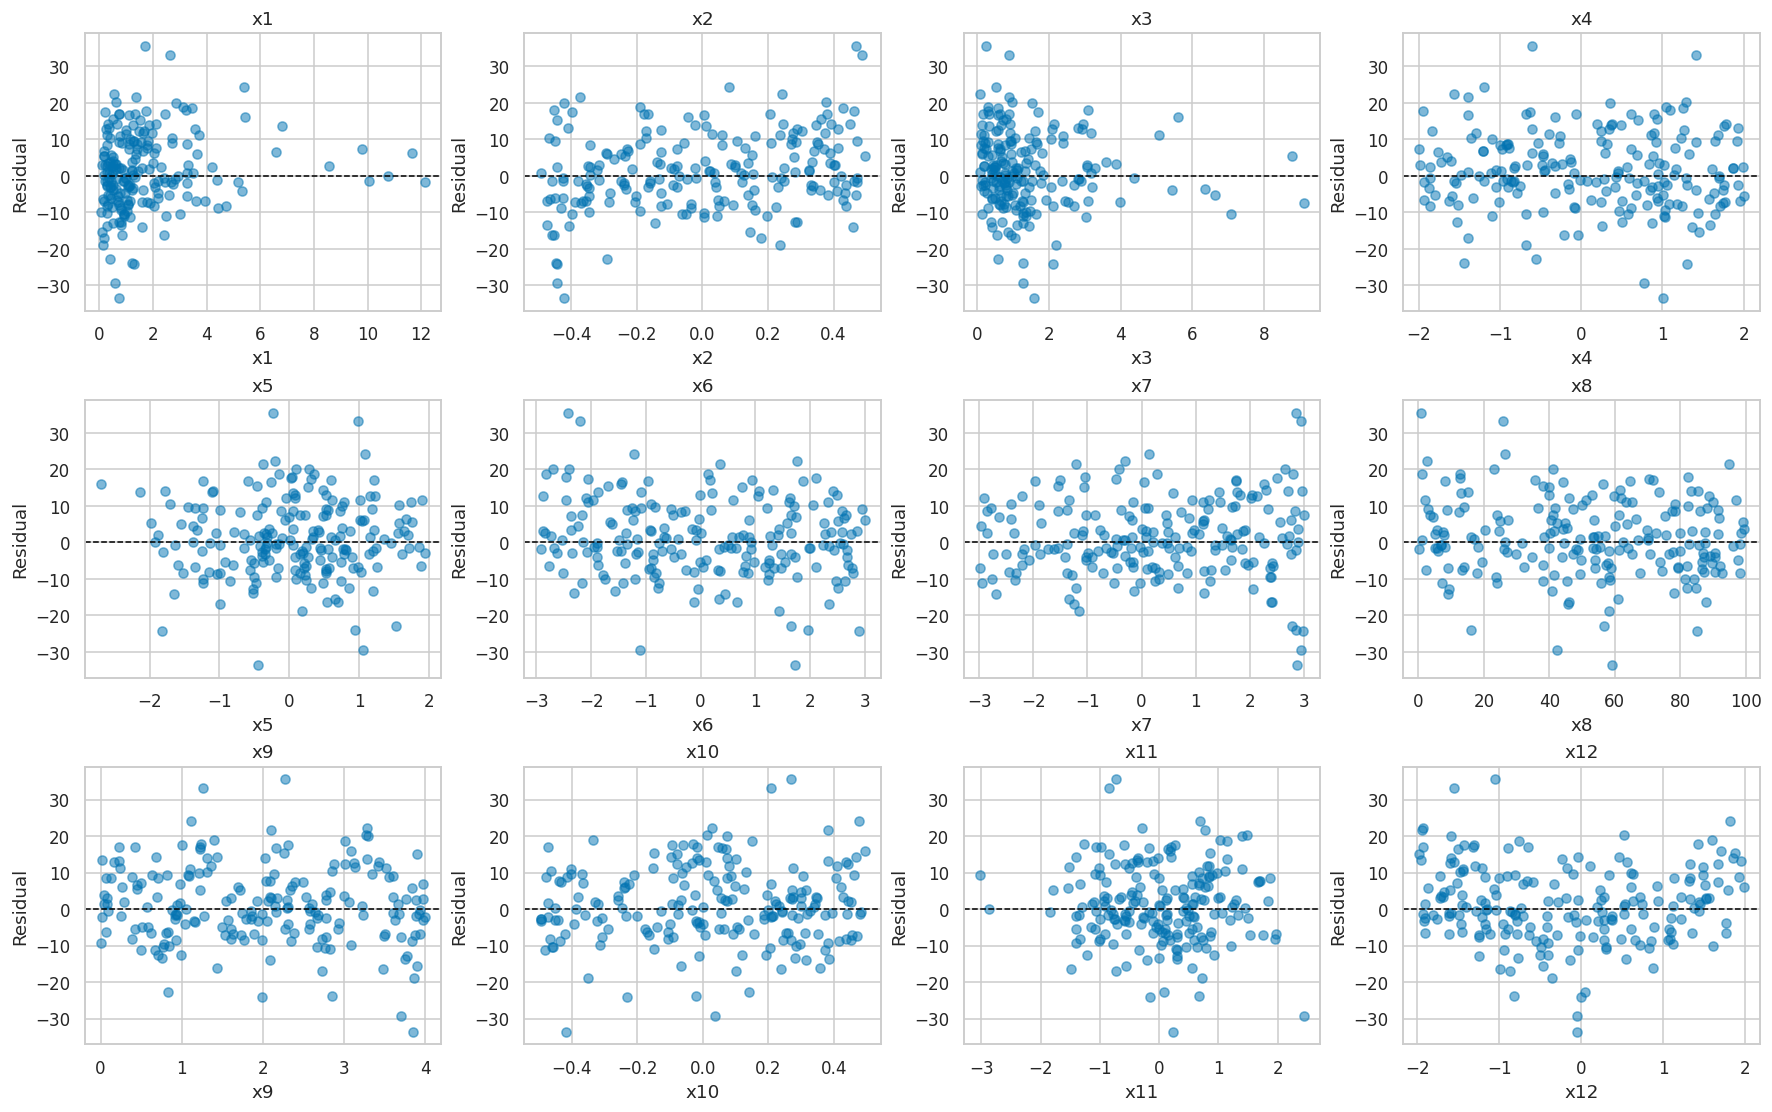

In [33]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales, alpha=0.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual")

plt.show()

In [34]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

# 1. Pruebas de transformaciones por separado 
modelo, mse, residuales, _ = ajusta({"x1_log": lambda d: np.log(d["x1"])})
print(f"MSE solo con x1 logarítmica: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x9_seno": lambda d: np.sin(d["x9"])})
print(f"MSE solo con x9 senoidal: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x12_cuadrada": lambda d: d["x12"] ** 2})
print(f"MSE solo con x12 al cuadrado: {mse:.2f}")

modelo, mse, residuales, _ = ajusta({"x3_log": lambda d: np.log(d["x3"])})
print(f"MSE con x3 logarítmica: {mse:.2f}")

# Prueba de la interacción de x1 y x3 por separado
modelo, mse, residuales, _ = ajusta({"x1_por_x3": lambda d: d["x1"] * d["x3"]})
print(f"MSE solo con interacción x1 * x3: {mse:.2f}")

#X1 y X3 me estaban dando muchos problemas asi que hice muchas pruebas
print("\n--- Pruebas individuales para x1 ---")
modelo, mse, _, _ = ajusta({"x1_log": lambda d: np.log(d["x1"] + 1e-5)}) # +1e-5 evita errores con ceros
print(f"MSE logaritmo: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x1_sqrt": lambda d: np.sqrt(d["x1"])})
print(f"MSE raíz cuadrada: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x1_cuadrada": lambda d: d["x1"] ** 2})
print(f"MSE cuadrado: {mse:.2f}")


print("\n--- Pruebas individuales para x3 ---")
modelo, mse, _, _ = ajusta({"x3_log_seguro": lambda d: np.log(d["x3"] + 1)}) # log(x+1) es seguro para ceros
print(f"MSE logaritmo seguro: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x3_sqrt": lambda d: np.sqrt(d["x3"])})
print(f"MSE raíz cuadrada: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x3_cuadrada": lambda d: d["x3"] ** 2})
print(f"MSE cuadrado: {mse:.2f}")

modelo, mse, _, _ = ajusta({"x3_inversa": lambda d: 1 / (d["x3"] + 1)})
print(f"MSE inversa: {mse:.2f}")

print("\n--- Prueba para x1 y x3 juntas ---")
modelo, mse, _, _ = ajusta({"x3+x1": lambda d: d["x3"] + d["x1"]}) # 
print(f"MSE x3+x1: {mse:.2f}")

# 2. Todas las transformaciones exitosas evaluadas de forma conjunta
transformaciones_combinadas = {
    "x1_log": lambda d: np.log(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}

modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"\nMSE con ajustes combinados_1: {mse_final:.2f}")

transformaciones_base = {
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}
modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_base)
print(f"MSE con ajustes combinados_2: {mse_final:.2f}")

transformaciones_combinadas = {
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x1_por_x3": lambda d: d["x1"] * d["x3"]
}

modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_combinadas)
print(f"MSE con ajustes combinados_3: {mse_final:.2f}")

MSE solo con x1 logarítmica: 108.80
MSE solo con x9 senoidal: 113.84
MSE solo con x12 al cuadrado: 96.38
MSE con x3 logarítmica: 112.72
MSE solo con interacción x1 * x3: 112.47

--- Pruebas individuales para x1 ---
MSE logaritmo: 108.80
MSE raíz cuadrada: 108.07
MSE cuadrado: 108.62

--- Pruebas individuales para x3 ---
MSE logaritmo seguro: 112.13
MSE raíz cuadrada: 112.26
MSE cuadrado: 112.40
MSE inversa: 112.24

--- Prueba para x1 y x3 juntas ---
MSE x3+x1: 112.51

MSE con ajustes combinados_1: 92.93
MSE con ajustes combinados_2: 97.74
MSE con ajustes combinados_3: 98.20


In [35]:
variables = [f"x{i}" for i in range(1, 13)]

print("--- Pruebas de interacción para x1 ---")
for var in variables:
    if var != "x1":
        # Evaluamos x1 multiplicado por cada una de las otras variables
        modelo, mse, _, _ = ajusta({f"x1_por_{var}": lambda d, col=var: d["x1"] * d[col]})
        print(f"MSE producto x1 y {var}: {mse:.2f}")
        

print("\n--- Pruebas de interacción para x3 ---")
for var in variables:
    if var != "x3":
        # Evaluamos x3 multiplicado por cada una de las otras variables
        modelo, mse, _, _ = ajusta({f"x3_por_{var}": lambda d, col=var: d["x3"] * d[col]})
        print(f"MSE producto x3 y {var}: {mse:.2f}")


--- Pruebas de interacción para x1 ---
MSE producto x1 y x2: 112.47
MSE producto x1 y x3: 112.47
MSE producto x1 y x4: 112.93
MSE producto x1 y x5: 112.81
MSE producto x1 y x6: 112.53
MSE producto x1 y x7: 113.33
MSE producto x1 y x8: 112.66
MSE producto x1 y x9: 112.15
MSE producto x1 y x10: 112.99
MSE producto x1 y x11: 112.65
MSE producto x1 y x12: 112.51

--- Pruebas de interacción para x3 ---
MSE producto x3 y x1: 112.47
MSE producto x3 y x2: 113.86
MSE producto x3 y x4: 112.60
MSE producto x3 y x5: 112.38
MSE producto x3 y x6: 112.58
MSE producto x3 y x7: 112.16
MSE producto x3 y x8: 113.24
MSE producto x3 y x9: 112.56
MSE producto x3 y x10: 112.46
MSE producto x3 y x11: 112.38
MSE producto x3 y x12: 114.25


In [36]:
variables = [f"x{i}" for i in range(1, 13)]

print("--- Pruebas de interacción para x1 ---")
for var in variables:
    if var != "x1":
        # Evaluamos x1 multiplicado por cada una de las otras variables
        modelo, mse, _, _ = ajusta({f"x1_por_{var}": lambda d, col=var: d["x1"] / d[col]})
        print(f"MSE division x1 y {var}: {mse:.2f}")
        

print("\n--- Pruebas de interacción para x3 ---")
for var in variables:
    if var != "x3":
        # Evaluamos x3 multiplicado por cada una de las otras variables
        modelo, mse, _, _ = ajusta({f"x3_por_{var}": lambda d, col=var: d["x3"] / d[col]})
        print(f"MSE division x3 y {var}: {mse:.2f}")

--- Pruebas de interacción para x1 ---
MSE division x1 y x2: 112.96
MSE division x1 y x3: 112.34
MSE division x1 y x4: 112.45
MSE division x1 y x5: 112.74
MSE division x1 y x6: 146.03
MSE division x1 y x7: 112.85
MSE division x1 y x8: 112.84
MSE division x1 y x9: 112.74
MSE division x1 y x10: 112.54
MSE division x1 y x11: 112.21
MSE division x1 y x12: 111.31

--- Pruebas de interacción para x3 ---
MSE division x3 y x1: 112.17
MSE division x3 y x2: 112.12


MSE division x3 y x4: 112.69
MSE division x3 y x5: 112.50
MSE division x3 y x6: 114.19
MSE division x3 y x7: 122.27
MSE division x3 y x8: 112.27
MSE division x3 y x9: 112.44
MSE division x3 y x10: 112.51
MSE division x3 y x11: 112.35
MSE division x3 y x12: 112.51


In [37]:
transformaciones_ganadoras = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}

print("--- Pruebas de interacción para x3 (con la base limpia) ---")
variables = [f"x{i}" for i in range(1, 13)]

for var in variables:
    if var != "x3":
        # Hacemos una copia del diccionario base para probar la interacción
        diccionario_prueba = transformaciones_ganadoras.copy()
        
        # Agregamos la interacción temporalmente
        diccionario_prueba[f"x3_por_{var}"] = lambda d, col=var: d["x3"] * d[col]
        
        modelo, mse, _, _ = ajusta(diccionario_prueba)
        print(f"MSE base + (x3 * {var}): {mse:.2f}")

--- Pruebas de interacción para x3 (con la base limpia) ---
MSE base + (x3 * x1): 92.39
MSE base + (x3 * x2): 93.63
MSE base + (x3 * x4): 92.36
MSE base + (x3 * x5): 92.43
MSE base + (x3 * x6): 92.49
MSE base + (x3 * x7): 91.83
MSE base + (x3 * x8): 92.36
MSE base + (x3 * x9): 92.34
MSE base + (x3 * x10): 92.44
MSE base + (x3 * x11): 92.21
MSE base + (x3 * x12): 93.23


In [38]:
transformaciones_finales = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x3_por_x7": lambda d: d["x3"] * d["x7"]
}

modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_finales)
print(f"MSE final consolidado: {mse_final:.2f}")

MSE final consolidado: 91.83


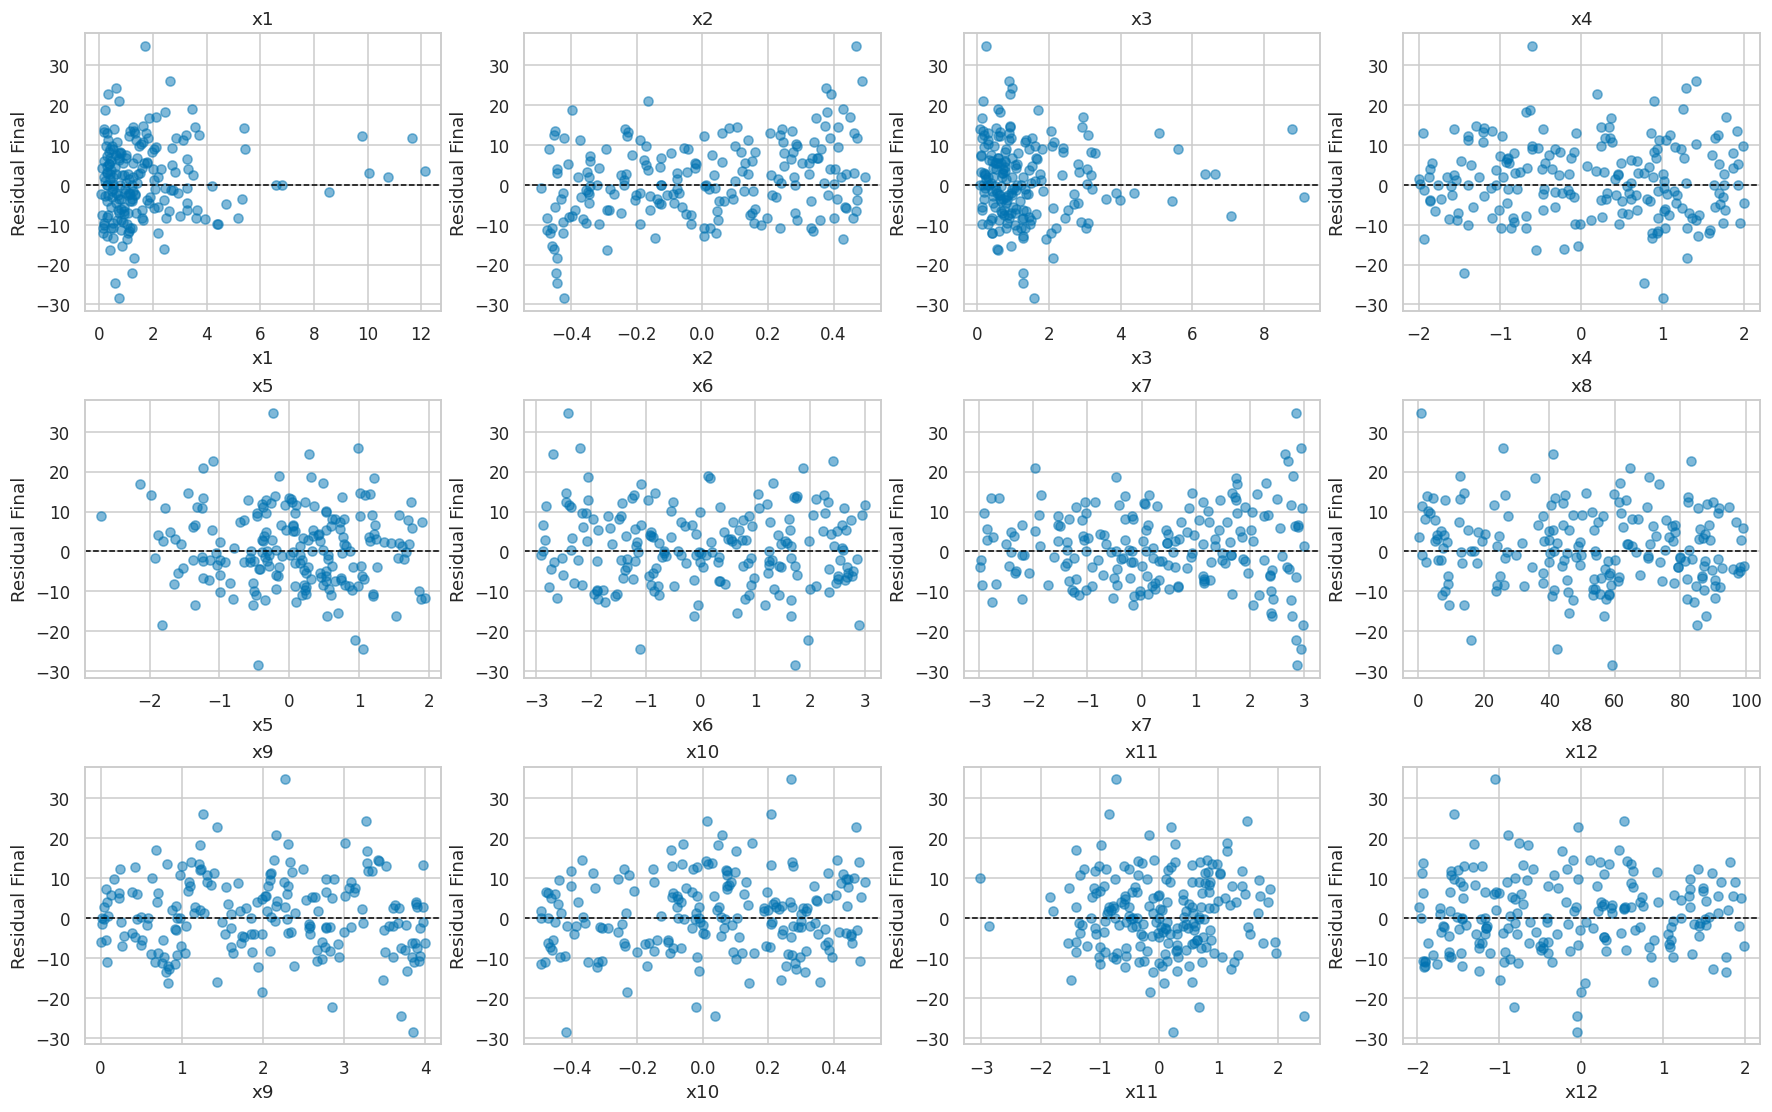

In [39]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales_final, alpha=0.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual Final")

plt.show()

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [40]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.

import itertools

transformaciones_base = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x3_por_x7": lambda d: d["x3"] * d["x7"]
}

print("--- Escaneando los 66 pares de variables ---")

resultados = []
# itertools.combinations crea todos los pares únicos posibles sin repetir
for var1, var2 in itertools.combinations(VARIABLES, 2):
    
    # Brincamos la interacción que ya descubriste antes
    if (var1 == "x3" and var2 == "x7") or (var1 == "x7" and var2 == "x3"):
        continue
        
    # Copiamos la base limpia
    diccionario_prueba = transformaciones_base.copy()
    
    # Agregamos la multiplicación de las dos variables en turno
    diccionario_prueba[f"{var1}_por_{var2}"] = lambda d, c1=var1, c2=var2: d[c1] * d[c2]
    
    # Ajustamos y guardamos el resultado
    modelo, mse, _, _ = ajusta(diccionario_prueba)
    resultados.append((mse, var1, var2))

# Ordenamos los resultados del MSE más bajo al más alto
resultados.sort()

print("\nLos 5 pares que más bajan el error:")
for mse, v1, v2 in resultados[:5]:
    print(f"MSE: {mse:.2f} -> {v1} * {v2}")

import itertools

# Modelo base SIN la interacción x3 * x7
transformaciones_base_alternativa = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2
}

print("\n--- Escaneando pares SIN x3*x7 en el modelo base ---")

resultados_alt = []

for var1, var2 in itertools.combinations(VARIABLES, 2):
    diccionario_prueba = transformaciones_base_alternativa.copy()
    
    # Agregamos la interacción a probar
    diccionario_prueba[f"{var1}_por_{var2}"] = lambda d, c1=var1, c2=var2: d[c1] * d[c2]
    
    modelo, mse, _, _ = ajusta(diccionario_prueba)
    resultados_alt.append((mse, var1, var2))

# Ordenamos del mejor (menor MSE) al peor
resultados_alt.sort()

print("\nTop 5 interacciones alternativas:")
for mse, v1, v2 in resultados_alt[:5]:
    print(f"MSE: {mse:.2f} -> {v1} * {v2}")

--- Escaneando los 66 pares de variables ---

Los 5 pares que más bajan el error:
MSE: 52.89 -> x2 * x7
MSE: 90.53 -> x6 * x7
MSE: 90.86 -> x2 * x4
MSE: 91.14 -> x6 * x9
MSE: 91.17 -> x9 * x10

--- Escaneando pares SIN x3*x7 en el modelo base ---

Top 5 interacciones alternativas:
MSE: 52.94 -> x2 * x7
MSE: 91.03 -> x6 * x7
MSE: 91.37 -> x2 * x4
MSE: 91.68 -> x9 * x12
MSE: 91.70 -> x6 * x9


In [41]:
# TODO: agreguen lo que hayan encontrado y midan.

# Consolidamos los hallazgos de la Parte 2 y la Parte 3
transformaciones_parte3 = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x3_por_x7": lambda d: d["x3"] * d["x7"], 
    "x2_por_x7": lambda d: d["x2"] * d["x7"]  
}

modelo_final, mse_final, residuales_final, _ = ajusta(transformaciones_parte3)
print(f"MSE con los hallazgos de la Parte 3: {mse_final:.2f}")

MSE con los hallazgos de la Parte 3: 52.89


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [42]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Construimos el pipeline con los 3 pasos sugeridos
modelo_fuerza_bruta = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=10000)
)

# Ajustamos el modelo con los datos de entrenamiento
modelo_fuerza_bruta.fit(X_train, y_train)

# Predecimos y evaluamos en validación
predicciones_lasso = modelo_fuerza_bruta.predict(X_val)
mse_lasso = mean_squared_error(y_val, predicciones_lasso)

# Extraemos el modelo LassoCV del pipeline para contar los coeficientes
lasso_entrenado = modelo_fuerza_bruta.named_steps['lassocv']
columnas_totales = len(lasso_entrenado.coef_)
columnas_activas = sum(lasso_entrenado.coef_ != 0)

print(f"Columnas generadas por PolynomialFeatures: {columnas_totales}")
print(f"Columnas distintas de cero (sobrevivientes): {columnas_activas}")
print(f"MSE de validación con LassoCV: {mse_lasso:.2f}")

Columnas generadas por PolynomialFeatures: 454
Columnas distintas de cero (sobrevivientes): 38
MSE de validación con LassoCV: 57.27


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación? El mio, fue de 4.38 unidades menor
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca. Le gano, porque `PolynomialFeatures` solo puede con combinaciones de polinomios enteros. Entre sus opciones no aplica la funcion sinoidal (sin(x9)) o las raizes (sqrt(x1))
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta? De haber ganado la fuerza bruta me hubiera indicado que hay alternativas que no he considerado
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800? Habria fallado, por las pocas observaciones es probable que hubiera un sobreajuste.

*(Su respuesta aquí)*

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [43]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    "x1_sqrt": lambda d: np.sqrt(d["x1"]),
    "x9_seno": lambda d: np.sin(d["x9"]),
    "x12_cuadrada": lambda d: d["x12"] ** 2,
    "x3_por_x7": lambda d: d["x3"] * d["x7"],
    "x2_por_x7": lambda d: d["x2"] * d["x7"],
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 52.89

Escrito: entregas/tarea-01/v86bd06c0/predicciones.csv
400 predicciones, rango -22.38 a 42.00


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.